## Evaluation pipeline for the microlane experiment

In [1]:
# First consider all the variables
# The input image gets resized to a particular level
# Then create a pipeline to feed data into the model
# AFter this process is completed, then process the data
# Then after the processing is done find a way to take output from the model
# Then, convert the output to relevant format, and store it for future use
# Apply relevant computations

In [2]:
# Imports of the Core Packages
import json, sys, time, pytz
import os, yaml,random 
import numpy as np
from datetime import datetime
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
# Import custom libraries located at different folder location + configs
from microlane.utils.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.models.lanenet2.model import LaneNet2
from microlane.schema.output import ModelPrediction
from microlane.schema.sample import Sample
from microlane.utils.load_image import load_image_from_sample

In [4]:
# First Load the Configuation file
with open("configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [5]:
# Create Details regarding the Experiment
# Modify settings from configs/config.yaml
# experiment_name = input("Enter the Name of the Experiment: ")
experiment_name = "lanenet2 initial testing"
experiment_name = experiment_name.lower().replace(" ", "_")

timezone = pytz.timezone("Asia/Kathmandu")  # NPT UTC+05:45
now = datetime.now(timezone)
timestamp = now.strftime("%Y_%m_%d__%H_%M_%S")
folder_name = f"{timestamp}_{experiment_name}"
print("Name of Experiment: ", folder_name)
# → 20260415_201537_resnet_baseline

Name of Experiment:  2026_04_15__21_46_59_lanenet2_initial_testing


### Pre Processing Part

In [6]:
# First initialise the dataset
# Then load the dataset
dataset = TuSimple(
    
        folder_path=config['data']['datasets']['tusimple']['path'],
        
        annotation_file_path=config['data']['datasets']['tusimple']['annotation_file']
    )

data = dataset.load(number=100)

### Processing Part where we do the Inference

In [ ]:
# So, basically now we will import the model
# model = LaneNet2() type and what we will do is, run 
# Run model.inference(formatted_dataset)

model = LaneNet2(
    
    container_folder=config['models']['lanenet2']['container_folder'],
    
    image_name=config['models']['lanenet2']['image_name']
    
)

In [8]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

random_image_index = random.randint(0, len(data)-1)

item = data[random_image_index]
print(f"Index        : {random_image_index}")
print(f"Image Path   : {item.image_path}")
print(f"h_samples    : {item.h_samples}")
print(f"lanes        : {item.lanes}")

Total items: 100

Index        : 65
Image Path   : /home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492627165541605354_0/20.jpg
h_samples    : [160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]
lanes        : [[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 640, 606, 572, 538, 504, 469, 435, 401, 367, 333, 299, 264, 230, 196, 162, 128, 94, 59, 25, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2], [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 692, 681, 671, 660, 648, 635, 623, 611, 602, 593, 583, 574, 565, 556, 546, 537, 528, 518, 509, 500, 490, 481, 472, 462, 453, 444, 434, 425, 416, 406, 397, 388, 378, 369, 360, 350, 341, 332, 322, 313, 304, 294, 285, 276, 266, 257], [-2, -2, -2, -2, -2, -2, -2,

In [9]:

loaded_image = load_image_from_sample(item)

In [10]:
# We are basically sending a loaded sample with actual image tensor in the memory

response = model.predict(loaded_image)

In [11]:
prediction = response.json()

ModelOutput = ModelPrediction (
    
    sample=Sample(
        
            image=prediction['sample']['image'],
            image_path=prediction['sample']['image_path'],
            h_samples=prediction['sample']['h_samples'],
            lanes=prediction['sample']['lanes'],
            blur=prediction['sample']['blur'],
            brightness=prediction['sample']['brightness'],
            zoom=prediction['sample']['zoom'],
            rotation=prediction['sample']['rotation']

        ),
    
    lanes=prediction['lanes'],
        
    inference_time=prediction['inference_time']
    
)

In [12]:


# Build the output object in the required format
output_entry = {
    "lanes": ModelOutput.lanes,
    "h_samples": ModelOutput.sample.h_samples,
    "raw_file": ModelOutput.sample.image_path,
    "inference_time": ModelOutput.inference_time
}

# Path to your JSON file
json_file_path = "results/predictions.json"

# Load existing data or start fresh
if os.path.exists(json_file_path):
    with open(json_file_path, "r") as f:
        data = json.load(f)
    # Handle both list format and single object format
    if not isinstance(data, list):
        data = [data]
else:
    data = []

# Append new entry
data.append(output_entry)

# Write back to file
with open(json_file_path, "w") as f:
    json.dump(data, f, indent=2)

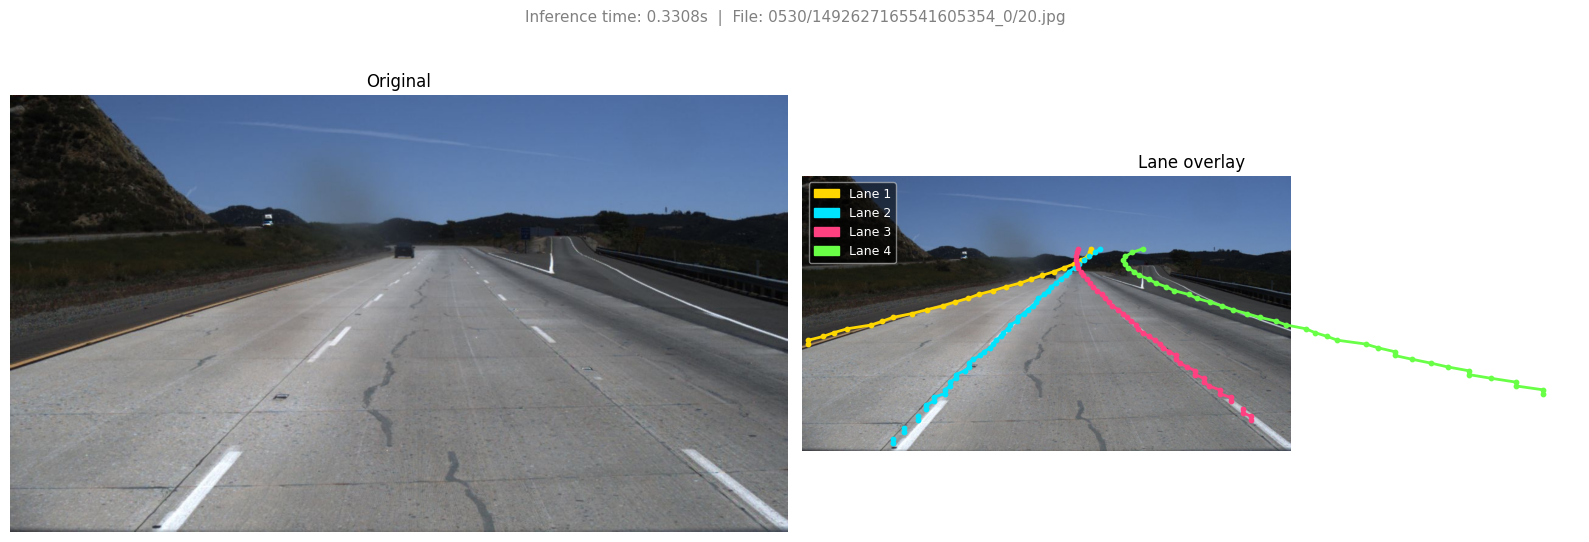

In [13]:


COLORS = ['#FFD700', '#00E5FF', '#FF4081', '#69FF47', '#FF6D00', '#E040FB']

img = Image.open(ModelOutput.sample.image_path)
img_arr = np.array(img)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Inference time: {ModelOutput.inference_time:.4f}s  |  "
    f"File: {'/'.join(ModelOutput.sample.image_path.split('/')[-3:])}",
    fontsize=11, color='gray'
)

axes[0].imshow(img_arr)
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(img_arr)
axes[1].set_title("Lane overlay", fontsize=12)
axes[1].axis("off")

legend_patches = []

for li, lane in enumerate(ModelOutput.lanes):
    color = COLORS[li % len(COLORS)]
    xs, ys = [], []

    for x, y in zip(lane, ModelOutput.sample.h_samples):
        if x == -2:
            if xs:
                axes[1].plot(xs, ys, color=color, linewidth=2)
                xs, ys = [], []
        else:
            xs.append(x)
            ys.append(y)

    if xs:
        axes[1].plot(xs, ys, color=color, linewidth=2)

    valid = [(x, y) for x, y in zip(lane, ModelOutput.sample.h_samples) if x != -2]
    if valid:
        vx, vy = zip(*valid)
        axes[1].scatter(vx, vy, color=color, s=10, zorder=5)

    legend_patches.append(mpatches.Patch(color=color, label=f"Lane {li+1}"))

axes[1].legend(handles=legend_patches, loc="upper left", fontsize=9,
               framealpha=0.6, facecolor='black', labelcolor='white')

plt.tight_layout()
plt.show()